# Classification

## The Dependent Variable

* Classification: y is discrete, categorical
* Classification is used to determine what group or category a particular y falls into

## Statistical Classification

In statistics, classification is the problem of identifying which of a set of categories (sub-populations) an observation (or observations) belongs to. Examples are assigning a given email to the "spam" or "non-spam" class, and assigning a diagnosis to a given patient based on observed characteristics of the patient (sex, blood pressure, presence or absence of certain symptoms, etc.).

https://en.wikipedia.org/wiki/Statistical_classification

In [1]:
# create dataframe from seaborn's iris dataset; print shape, info, and head
# https://docs.kedro.org/en/0.17.5/02_get_started/05_example_project.html
import pandas as pd
import seaborn as sns

df = sns.load_dataset('iris')
print(df.shape)
print(df.info())
df.head()

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [3]:
# train test split using 25% for test size; print X_train shape and head
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('species', axis=1), 
                                                    df['species'], 
                                                    test_size=0.25, 
                                                    random_state=42)

X_train.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,112.000000,112.000000,112.000000,112.000000
mean,5.830357,3.040179,3.807143,1.214286
std,0.819123,0.437120,1.735310,0.747953
min,4.300000,2.000000,1.100000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.700000,4.200000,6.700000,2.500000


In [4]:
y_train.head()

4          setosa
32         setosa
142     virginica
85     versicolor
86     versicolor
Name: species, dtype: object

In [5]:
# map species (y_train)
y_train = y_train.map({'setosa':0,'versicolor':1, 'virginica':2})
y_test = y_test.map({'setosa':0,'versicolor':1, 'virginica':2})
y_train.head()

4      0
32     0
142    2
85     1
86     1
Name: species, dtype: int64

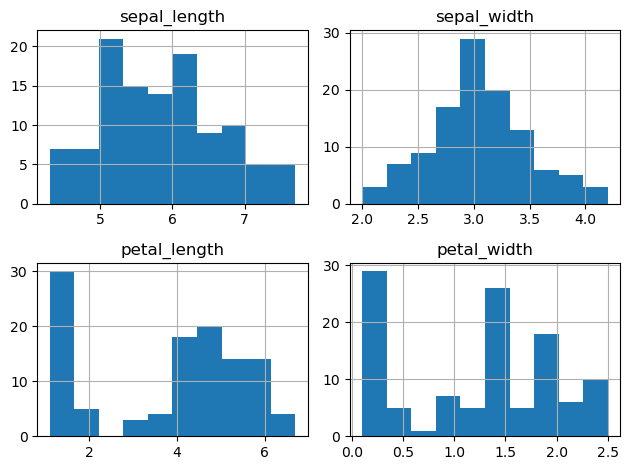

In [6]:
# show histograms
import matplotlib.pyplot as plt

X_train.hist()
plt.tight_layout()

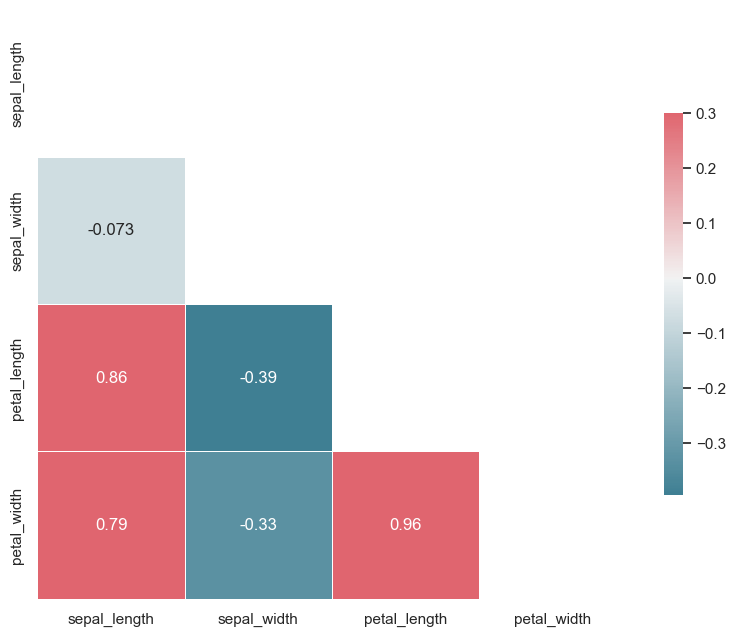

In [7]:
# correlation heat map
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# correlation matrix
sns.set(style="white")

# compute the correlation matrix
corr = X_train.corr()

# generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# set up the matplotlib figure
# f, ax = plt.subplots()
f = plt.figure(figsize=(8, 8))

# generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True);

plt.tight_layout()

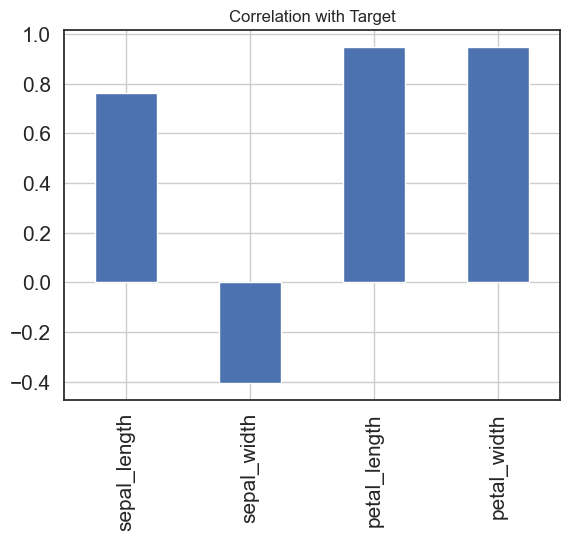

In [8]:
# corrwith target
X_train._get_numeric_data().corrwith(y_train).plot.bar(
        title = "Correlation with Target", fontsize = 15,
        rot = 90, grid = True);

In [9]:
# Create model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train,y_train)
predictions = model.predict(X_test)

In [10]:
score = model.score(X_test, y_test)
print('Test Accuracy Score: ', score)

Test Accuracy Score:  1.0


In [11]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

1.0